In [31]:
#导入体能训练数据集
from sklearn.datasets import load_linnerud
#导入numpy和panda和matplotlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#导入lasso回归和ridge回归模型
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
#导入划分集合的train_test_split
from sklearn.model_selection import train_test_split
#导入标准化函数包StandardScaler
from sklearn.preprocessing import StandardScaler

In [32]:
#导入中文模块
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

#引用linnerud数据集
linnerud=load_linnerud()
X=linnerud.data
y=linnerud.target
#设置中文标签
feature_names=['体重','腰围','脉搏']
target_names=['引体向上','仰卧起坐','跳高']

df_x=pd.DataFrame(X,columns=feature_names)
df_y=pd.DataFrame(y,columns=target_names)
print(df_x.head(5))
print(df_y.head(5))

     体重     腰围     脉搏
0   5.0  162.0   60.0
1   2.0  110.0   60.0
2  12.0  101.0  101.0
3  12.0  105.0   37.0
4  13.0  155.0   58.0
    引体向上  仰卧起坐    跳高
0  191.0  36.0  50.0
1  189.0  37.0  52.0
2  193.0  38.0  58.0
3  162.0  35.0  62.0
4  189.0  35.0  46.0


In [33]:
#把数据分成训练集和测试集
X_train, X_test, y_train, y_test =  train_test_split(X, y, random_state=12, test_size=0.3)
#数据预处理
#对X和y数据进行标准化
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)
y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

In [34]:
#列举部分alpha
ridge_alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000]#ridge回归所用的alpha
lasso_alphas = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]#lasso回归使用的alpha
#储存不同alpha下lasso回归和ridge回归的结果
r_result=[]#存放ridge回归的结果R**2
l_result=[]#存放lasso回归的结果R**2

In [35]:
#求出每个alpha对应的ridge回归的R**2
#ridge_alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
for alphas in ridge_alphas:
    ridge = Ridge(alpha=alphas) #调用ridge回归模型
    ridge.fit(X_train_scaled, y_train_scaled) #用训练集进行训练
    r_result.append(ridge.score(X_test_scaled, y_test_scaled)) #把alpha对应的R***2放入列表

In [36]:
#求出每个alpha对应的lasso回归的R**2
#lasso_alphas = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]
for alphas in lasso_alphas:
    lasso = Lasso(alpha=alphas) #调用lasso回归模型
    lasso.fit(X_train_scaled, y_train_scaled) #用训练集进行训练
    l_result.append(lasso.score(X_test_scaled, y_test_scaled)) #把alpha对应的R***2放入列表

In [37]:
#输出结果
print("ridge回归的alpha",ridge_alphas)
print("ridge回归的R**2",r_result)
print("lasso回归的alpha",lasso_alphas)
print("lasso回归的R**2",l_result)

ridge回归的alpha [0.001, 0.01, 0.1, 1, 10, 100, 1000]
ridge回归的R**2 [0.09259047187912468, 0.09284752937907526, 0.09533679021452401, 0.11379572091348922, 0.13283541453395417, 0.027831111698606043, -0.03373407438481798]
lasso回归的alpha [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]
lasso回归的R**2 [0.09262370542760896, 0.09318504585530167, 0.09799843362865131, 0.13728410907388813, -0.043388912023953084, -0.043388912023953084, -0.043388912023953084]


In [38]:
# 找到岭回归中R²最高值对应的alpha
best_ridge_alpha = ridge_alphas[np.argmax(r_result)]
print("best_ridge_alpha=",best_ridge_alpha)
# 岭回归的最佳R²分数
best_ridge_score = max(r_result)
print("best_ridge_score=",best_ridge_score)
# 找到Lasso回归中R²最高值对应的alpha
best_lasso_alpha = lasso_alphas[np.argmax(l_result)]
print("best_lasso_alpha=",best_lasso_alpha)
# Lasso回归的最佳R²分数
best_lasso_score = max(l_result)
print("best_lasso_score=",best_lasso_score)

best_ridge_alpha= 10
best_ridge_score= 0.13283541453395417
best_lasso_alpha= 0.1
best_lasso_score= 0.13728410907388813


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

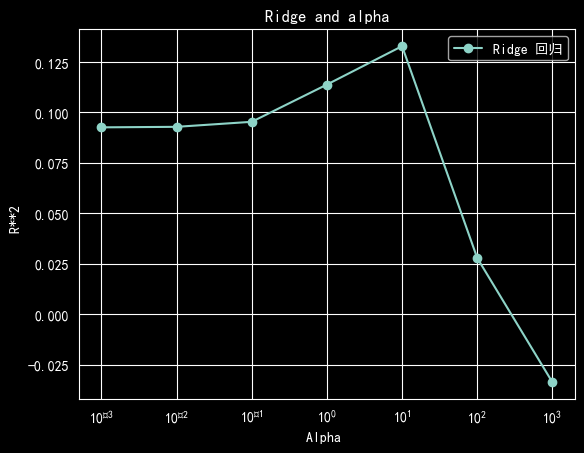

In [39]:
# 绘制 ridge 回归不同 alpha 值的性能
plt.plot(ridge_alphas, r_result, 'o-', label='Ridge 回归')  # 'o-'表示带圆点的折线图
plt.xscale('log')      # x轴（alpha值）采用对数刻度，因为alpha跨度大
plt.xlabel('Alpha ')   # x轴标签：正则化强度参数
plt.ylabel('R**2 ')    # y轴标签：拟合优度（越接近1拟合越好）
plt.title('Ridge and alpha')  # 图表标题
plt.grid(True)         # 显示网格，便于查看数值
plt.legend()           # 显示图例
plt.show()             # 显示图表

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

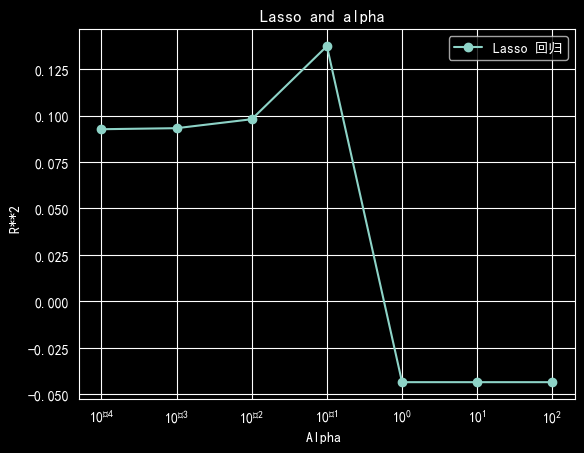

In [40]:
# 绘制 Lasso 回归不同 alpha 值的性能
plt.plot(lasso_alphas, l_result, 'o-', label='Lasso 回归')  # 'o-'带圆点折线图，显示alpha与R²关系
plt.xscale('log')      # x轴对数刻度（alpha值跨度大，对数刻度更清晰）
plt.xlabel('Alpha ')   # x轴：正则化参数（越大正则化越强）
plt.ylabel('R**2 ')    # y轴：拟合优度（评估模型性能）
plt.title('Lasso and alpha ')  # 图表标题
plt.grid(True)         # 显示网格线
plt.legend()           # 显示图例
plt.show()             # 渲染显示图表